<a href="https://colab.research.google.com/github/harshavardhanbommalla-glitch/numpy_scores.ipynb/blob/main/copy_of_untitled.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 200

data = {
    "order_id": range(1001, 1001 + n),
    "city": np.random.choice(["Mumbai", "Delhi", "Bangalore", "Chennai"], size=n),
    "category": np.random.choice(["Electronics", "Clothing", "Groceries", "Furniture"], size=n),
    "order_value": np.random.randint(200, 5000, size=n).astype(float),
    "delivery_days": np.random.randint(1, 15, size=n).astype(float),
    "rating": np.random.choice([1, 2, 3, 4, 5, None], size=n)
}

missing_indices_order = np.random.choice(n, size=15, replace=False)
missing_indices_delivery = np.random.choice(n, size=10, replace=False)
data["order_value"][missing_indices_order] = np.nan
data["delivery_days"][missing_indices_delivery] = np.nan

data["order_value"][5] = 95000
data["order_value"][88] = 87000

df = pd.DataFrame(data)
print(df.shape)
df.head()


(200, 6)


,order_id,city,category,order_value,delivery_days,rating
0,1001,Bangalore,Groceries,4191.0,11.0,4
1,1002,Chennai,Furniture,4923.0,12.0,1
2,1003,Mumbai,Groceries,4882.0,13.0,2
3,1004,Bangalore,Electronics,1848.0,13.0,1
4,1005,Bangalore,Furniture,1645.0,12.0,1


In [ ]:
print(df.dtypes)

order_id           int64
city              object
category          object
order_value      float64
delivery_days    float64
rating            object
dtype: object


In [ ]:
missing_count = df.isnull().sum()
print("\nMissing Values Count:\n", missing_count)


Missing Values Count:
 order_id          0
city              0
category          0
order_value      14
delivery_days    10
rating           32
dtype: int64


In [ ]:
percentage_missing = (df.isnull().sum() / len(df)) * 100
print("\nPercentage of missing values in each column:")
print(percentage_missing.round(2))


Percentage of missing values in each column:
order_id          0.0
city              0.0
category          0.0
order_value       7.0
delivery_days     5.0
rating           16.0
dtype: float64


In [ ]:
df.describe()

,order_id,order_value,delivery_days
count,200.000000,186.000000,190.000000
mean,1100.500000,3707.134409,7.810526
std,57.879185,9238.438378,4.075465
min,1001.000000,204.000000,1.000000
25%,1050.750000,1512.000000,4.000000
50%,1100.500000,2934.000000,8.000000
75%,1150.250000,3987.500000,12.000000
max,1200.000000,95000.000000,14.000000


- The order_value column has a maximum of 95,000, which is drastically higher than the 75th percentile (≈ 3,987.5). This indicates the presence of extreme outliers that heavily skew the distribution.
- The delivery_days column shows a median of 8 and a mean of about 7.8, with values ranging only between 1 and 14. This suggests delivery times are fairly consistent and balanced, without extreme deviations.


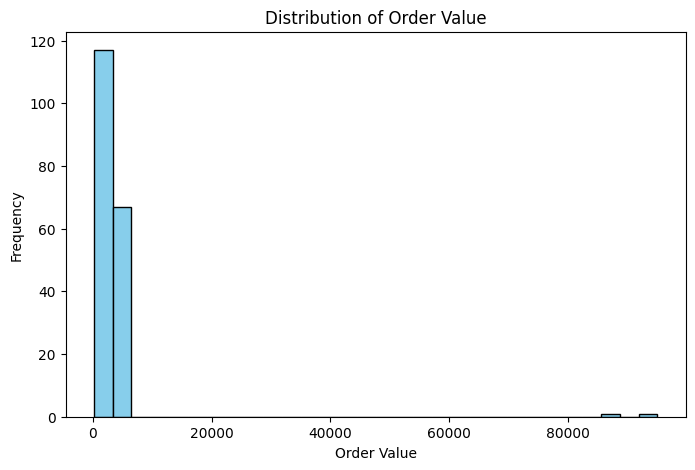

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df['order_value'].dropna(), bins=30, color='skyblue',edgecolor='black')
plt.title("Distribution of Order Value")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.show()

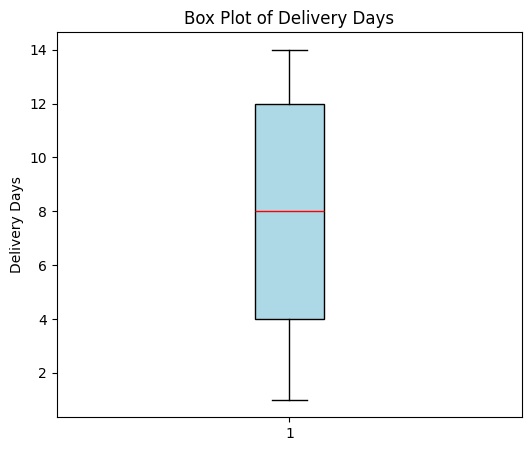

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
plt.boxplot(
    df['delivery_days'].dropna(),
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='black'),
    medianprops=dict(color='red')
)
plt.title("Box Plot of Delivery Days")
plt.ylabel("Delivery Days")
plt.show()

In [ ]:
# Compute correlation matrix for numerical columns
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)

               order_id  order_value  delivery_days
order_id       1.000000    -0.095503       0.004858
order_value   -0.095503     1.000000       0.141660
delivery_days  0.004858     0.141660       1.000000


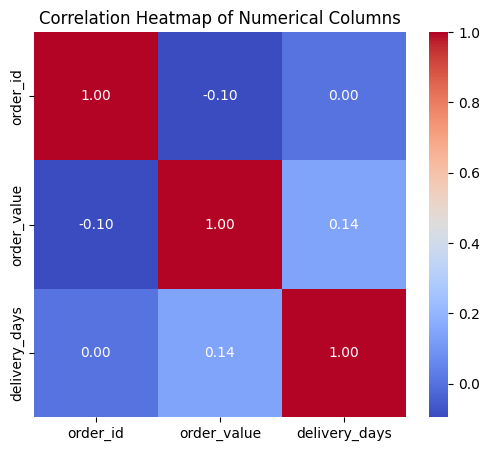

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Columns")
plt.show()

- Notable Positive Relationship: order_value and delivery_days show a slight positive correlation. This suggests that larger orders may take longer to deliver.
- Weak/No Relationship: order_id has near-zero correlation with all other columns, confirming it’s just a sequential identifier.
